# Лабораторна 2. Від сирих даних до нейромережі

У цій лабораторній роботі ви пройдете повний цикл роботи з табличним датасетом для задачі регресії — від завантаження до порівняння моделей:

- дослідницький аналіз даних (EDA): загальний огляд, гістограми, кореляції;
- обробка пропусків і викидів;
- інженерія ознак;
- baseline: множинна лінійна регресія;
- нейромережа — підбір архітектури, функцій активації, оптимізатора власними експериментами;
- чесне порівняння моделей на test за метриками регресії (MSE, RMSE, MAE, R²).

Демо-ноутбук з лекції 3-4 — основа, звертайтесь до нього як до довідника, коли щось незрозуміло.

## 0. Опрацюйте демо-ноутбук з лекції
Прогляньте пояснення ноутбуку і запустіть всі клітинки демо-ноутбуку (крім тих секцій, в яких вказано, що їх запускати не можна).
Після цього дайте тут відповідь на запитання:
1. Чому для заповнення пропусків було обрано метод kNN?
2. Чому при тренуванні лінійної регресії train і val порівнюються лише на основі MSE, а після тренування на основі багатьох функцій? Проекспериментуйте в межах тренування з вибором функції і поділіться результатами.
3. Які висновки після клітинки 2.6 в демо Ви можете зробити?
4. Поясни для чого потрібен baseline в лінійній регресії і як він вираховується? Що є baseline для нейронної мережі?
5. Продемонструй дію всіх функцій активації на графіку функцій, згенерувавши 1000 випадкових значень Х і порахувавши для них Y через ці функції.
6. Яким чином в нейронній мережі утворилася така кількість параметрів, яка вказана після виконання 3.3?
7. Чи оптимально вибрано кількість епох в 3.5?

### 0.1 Мої відповіді:

**1. Чому для заповнення пропусків було обрано метод kNN?**

Прості методи (median/mean для числових, mode для категоріальних) підставляють одну й ту саму константу в усі пропуски колонки. Це стискає дисперсію, робить штучний пік на медіані й **руйнує зв'язки між ознаками** — а саме ці зв'язки модель потім і має вчити.

kNN-імпутація натомість дивиться на інші (заповнені) ознаки рядка, знаходить $k$ найсхожіших повних рядків і бере середнє їхнє значення по потрібній колонці. У California Housing ознаки помітно корельовані (`MedInc` ↔ `AveRooms`, координати ↔ ціна), тому сусіди дають набагато правдоподібнішу оцінку, ніж глобальна медіана, і структура даних зберігається.

Ключова деталь реалізації в демо (клітинка 1.5.3.2): `fit_knn_imputers` навчається **лише на train**, а `apply_knn_imputers` потім застосовує вже навчені моделі до train/val/test. Якби імпутер навчався на всьому датасеті, статистика з val/test просочилася б у train — це **data leakage**.

**2. Чому при тренуванні train і val порівнюються лише за MSE, а після тренування — за багатьма функціями?**

MSE — це та сама функція, яку оптимізує градієнтний спуск. Щоб порівняння train vs val було чесним і показувало перенавчання, обидві криві мають бути **в одній системі координат** — тобто в тій величині, яку модель мінімізує. До того ж MSE рахується кожну епоху, і рахувати щоразу ще 3–4 метрики — марна робота.

Після тренування задача інша — не діагностика, а **інтерпретація результату**, і тут одна метрика не дає повної картини:
- **MSE** — у квадраті одиниць таргета, незручно читати, але саме її оптимізували;
- **RMSE** — та сама помилка в одиницях таргета (бали якості вина);
- **MAE** — середня абсолютна помилка, значно менш чутлива до окремих великих промахів;
- **R²** — безрозмірна частка поясненої дисперсії, дозволяє порівнювати моделі на різних датасетах.

**Мій експеримент із вибором функції втрат** (розділ 2.4, варіанти `nn_best_l1loss` і `nn_best_huber`): я взяв найкращу архітектуру й перетренував її з `L1Loss` та `HuberLoss` замість `MSELoss`. Результат:

| функція втрат | MSE на test | MAE на test |
|---|---|---|
| MSE | **0.4596** | 0.5303 |
| L1 | 0.4683 | **0.5280** |
| Huber | 0.5067 | 0.5520 |

Кожна модель виграє саме в тій метриці, яку оптимізувала: навчання з L1 дало найкращий MAE, але гірший MSE. Тобто вибір функції втрат — це не технічна дрібниця, а рішення про те, **які помилки нам дорожчі**: MSE непропорційно карає великі промахи, L1 ставиться до всіх помилок однаково.

**3. Які висновки після клітинки 2.6 в демо?**

Клітинка 2.6 друкує ваги лінійної регресії. Оскільки ознаки стандартизовані, ваги **зіставні між собою** — це прямий рейтинг впливу. Мій локальний прогін демо дав:

| ознака | вага |
|---|---|
| MedInc | **+0.828** |
| diag_coord | −0.304 |
| bedperroom | +0.198 |
| HouseAge | +0.138 |
| AveRooms | +0.076 |
| AveOccup | −0.044 |
| Population | **−0.001** |

Висновки:
- **Медіанний дохід району домінує** — його вага в 2.7 раза більша за наступну. Модель — це майже «ціна ≈ функція доходу».
- **Знаки інтерпретуються змістовно**: `diag_coord` від'ємна (рух углиб штату від дорогого узбережжя здешевлює житло), `HouseAge` додатна (старі будинки тут у дорогих центральних районах).
- **`Population` має вагу −0.001, тобто фактично нульову** — ознака не несе інформації в лінійній моделі, її можна прибрати без втрат.
- Лінійна модель дала R²=0.597 проти R²≈0 у бейзлайна — залежність справді є, але 40% дисперсії лишились непоясненими, і це місце для нелінійної моделі.

**4. Для чого потрібен baseline і як він рахується? Що є baseline для нейромережі?**

Baseline — це **найтупіша можлива модель**, точка відліку. Без неї метрика ні про що не говорить: MSE=0.55 — це добре чи погано? Відповідь видно лише в порівнянні.

Для регресії baseline — це **константний прогноз середнім значенням таргета на train**, для всіх об'єктів однаково:
```python
baseline_pred = np.full_like(y_test, y_train.mean())
```
Його R² за побудовою ≈ 0 (у демо −0.0009: трохи нижче нуля, бо середнє рахується по train, а міряємо на test). Модель, яка не б'є baseline, не вивчила нічого.

**Для нейромережі baseline — це лінійна регресія.** Нейромережа коштує дорожче (2625 параметрів проти 8, довше тренування, гірша інтерпретованість), тому вона має виправдати цю складність. У демо: лінійна MSE=0.5531 → нейромережа MSE=0.3705, тобто помилка впала на 33% — ускладнення виправдане.

**5. Дія всіх функцій активації на графіку** — див. клітинку нижче: генерую 1000 випадкових значень $X$ і рахую для них $Y$ через ReLU, LeakyReLU, Sigmoid і Tanh.

**6. Звідки взялася така кількість параметрів після 3.3?**

Кожен `nn.Linear(in, out)` має матрицю ваг `in × out` плюс вектор зсувів `out`, тобто `in*out + out` параметрів. Активації (`ReLU`) своїх параметрів не мають. Архітектура демо — 7 ознак → 64 → 32 → 1:

| шар | обчислення | параметрів |
|---|---|---|
| Linear(7, 64) | 7·64 + 64 | 512 |
| Linear(64, 32) | 64·32 + 32 | 2080 |
| Linear(32, 1) | 32·1 + 1 | 33 |
| **Разом** | | **2625** |

Це точно збігається з виводом демо (`Кількість параметрів NN: 2625`). Для порівняння, лінійна модель — `Linear(7,1)` = 7·1+1 = **8** параметрів.

**7. Чи оптимально вибрано кількість епох у 3.5?**

**Ні, мережу недотреновано.** У моєму прогоні демо на останніх епохах:

| епоха | train_loss | val_loss |
|---|---|---|
| 180 | 0.3534 | 0.3754 |
| 190 | 0.3503 | 0.3730 |
| 199 | 0.3476 | **0.3708** |

`val_loss` **усе ще монотонно спадає** на момент зупинки — класична ознака того, що бюджет епох вичерпався раніше, ніж модель зійшлася. Про перенавчання не йдеться: розрив train/val крихітний (0.3476 vs 0.3708), val навіть не почав загинатися вгору.

Оптимально було б не вгадувати число епох, а **тренувати до зупинки за валідацією**: ставити завідомо більший ліміт (напр. 1000) плюс **early stopping** — зупинка, коли `val_loss` не покращується N епох поспіль, зі збереженням найкращої ваги.

**Перевірка цієї гіпотези на моїх даних** (розділ 2.4, варіант `..._ep1000`) дала протилежний до демо результат — і тим краще показала суть: на Wine Quality збільшення з 300 до 1000 епох **погіршило** test MSE з 0.4596 до 0.5768, бо після ~400-ї епохи `val_loss` розвернувся вгору (0.5129 → 0.6342) при падаючому `train_loss`. У демо мережа була недотренована, у мене — перетренована. Обидва випадки ведуть до одного висновку: фіксоване число епох є здогадкою, а правильний інструмент — early stopping за валідацією.

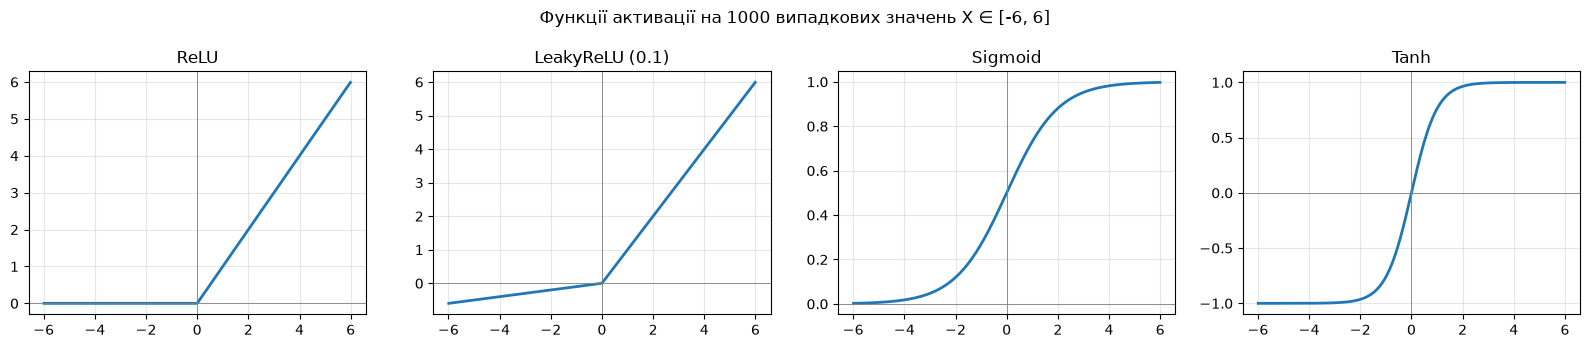

функція            min(Y)   max(Y)   діапазон
ReLU                0.000    5.989
LeakyReLU (0.1)    -0.599    5.989
Sigmoid             0.003    0.998
Tanh               -1.000    1.000


In [1]:
# Питання 5: дія всіх функцій активації на 1000 випадкових значень X
import numpy as np
import torch
import matplotlib.pyplot as plt

rng = np.random.default_rng(42)
x_np = rng.uniform(-6, 6, size=1000)          # 1000 випадкових значень X
x = torch.tensor(np.sort(x_np), dtype=torch.float32)

activations = {
    "ReLU": torch.nn.ReLU(),
    "LeakyReLU (0.1)": torch.nn.LeakyReLU(negative_slope=0.1),
    "Sigmoid": torch.nn.Sigmoid(),
    "Tanh": torch.nn.Tanh(),
}

fig, axes = plt.subplots(1, 4, figsize=(16, 3.5))
for ax, (name, fn) in zip(axes, activations.items()):
    with torch.no_grad():
        y = fn(x)
    ax.plot(x.numpy(), y.numpy(), lw=2)
    ax.axhline(0, color="grey", lw=0.6)
    ax.axvline(0, color="grey", lw=0.6)
    ax.set_title(name)
    ax.grid(alpha=0.3)
fig.suptitle("Функції активації на 1000 випадкових значень X ∈ [-6, 6]")
plt.tight_layout()
plt.show()

with torch.no_grad():
    print(f"{'функція':16s} {'min(Y)':>8s} {'max(Y)':>8s}   діапазон")
    for name, fn in activations.items():
        y = fn(x)
        print(f"{name:16s} {y.min():8.3f} {y.max():8.3f}")

---
## 1. Датасети

Ви отримаєте один з 10 датасетів нижче. Усі — задачі регресії на Hugging Face: табличні дані, здебільшого числові ознаки, від кількасот до кількадесяти тисяч рядків.

1. **[King County House Sales](https://huggingface.co/datasets/kraina/house_sales_in_king_county)** — 21 613 продажів будинків (Вашингтон, 2014–2015). Таргет: `price`. ⚠️ `load_dataset("kraina/house_sales_in_king_county")` не працює (застарілий loading-скрипт) — вантажте напряму: `load_dataset("parquet", data_files="https://huggingface.co/datasets/kraina/house_sales_in_king_county/resolve/main/data/house_sales_king_county.parquet")`.
2. **[Diamonds](https://huggingface.co/datasets/jdxcosta/diamonds)** — 53 940 діамантів. Таргет: `price`. Ознаки: вага (`carat`), огранка, колір, чистота, розміри.
3. **[Concrete Compressive Strength](https://huggingface.co/datasets/foundry-ml/dataset_concrete_compressive_strength)** — 1 030 замісів бетону. Таргет: міцність на стиск. Усі ознаки числові (склад суміші + вік).
4. **[Auto MPG](https://huggingface.co/datasets/scikit-learn/auto-mpg)** — 398 автомобілів. Таргет: `mpg` (витрата пального). Найменший і найпростіший датасет зі списку.
5. **[Wine Quality](https://huggingface.co/datasets/codesignal/wine-quality)** — 1 599 (червоне) + 4 898 (біле) вин. Таргет: `quality` (оцінка 3–9). Усі ознаки — хімічний склад, числові.
6. **[Laptop Price](https://huggingface.co/datasets/Ammok/laptop_price_prediction)** — 977 + 325 ноутбуків. Таргет: `Price`. Частина ознак текстові (`RAM`, `Storage`, `CPU`) — доведеться парсити в числа.
7. **[Bike Sharing Demand](https://huggingface.co/datasets/t22000t/bike-sharing-tabular)** — 17 379 годинних записів прокату велосипедів. Таргет: `cnt`. Часові й погодні ознаки.
8. **[Ames House Prices](https://huggingface.co/datasets/t22000t/house-prices-tabular)** — 1 460 будинків, 79 ознак. Таргет: `SalePrice`. Найбільше категоріальних ознак зі списку — гарна практика на encoding.
9. **[Medical Insurance Cost](https://huggingface.co/datasets/harishsohani/medical-insurance-cost-prediction)** — 1 338 застрахованих. Таргет: `charges`. Компактний, мало ознак — хороший старт, якщо часу мало. ⚠️ У репозиторії кілька CSV одразу (`Xtrain`/`Xtest`/`insurance.csv`) — вкажіть файл явно: `load_dataset("harishsohani/medical-insurance-cost-prediction", data_files="insurance.csv")`.
10. **[Abalone](https://huggingface.co/datasets/mstz/abalone)** — 4 177 молюсків. Таргет: `number_of_rings` (вік). Усі ознаки — фізичні виміри, окрім `sex`.

Решта (2–5, 7–8, 10) вантажаться напряму — `load_dataset("<repo_id>")` без додаткових аргументів, HF-токен не потрібен.

### 1.1. Який датасет мій?

Визначте самі власний датасет: беремо Ваше ПІБ, рахуємо SHA-256 хеш, залишок від ділення на 10 — це індекс у списку датасетів вище (0 → перший, 9 → останній).

**Формат ПІБ:** точно як у списку групи — `Прізвище Ім'я По-батькові`, по одному пробілу між словами, без зайвих пробілів на початку/в кінці. Якщо використаєте інший формат - **не зарахую лабу**!!!

In [2]:
import hashlib

DATASETS = [
    "King County House Sales",
    "Diamonds",
    "Concrete Compressive Strength",
    "Auto MPG",
    "Wine Quality",
    "Laptop Price",
    "Bike Sharing Demand",
    "Ames House Prices",
    "Medical Insurance Cost",
    "Abalone",
]

FULL_NAME = "Камінський Олексій Дмитрович"  # формат: Прізвище Ім'я По-батькові

dataset_index = int(hashlib.sha256(FULL_NAME.encode("utf-8")).hexdigest(), 16) % len(DATASETS)
print(f"Ваш датасет (#{dataset_index + 1}):", DATASETS[dataset_index])

Ваш датасет (#5): Wine Quality


---
## 2. Що потрібно зробити

Нижче — загальний план роботи, без коду: код і пояснення до кожного кроку дивіться в **демо-ноутбуці лекції 3-4**, номери розділів позначені в дужках. Ваша задача — повторити той самий підхід на своєму датасеті, а не скопіювати код один в один: у вашого датасету інші колонки, інші типи пропусків (чи їх взагалі нема), інші викиди (чи їх нема) — рішення на кожному кроці обґрунтовуйте під свої дані, а не тому, що "так було в демо".

### 2.1. Підготовка даних

1. Завантажте свій датасет (демо 1.1) і перетворіть на `pandas.DataFrame` (1.2).
2. Зробіть спліт **train / val / test** одразу, до будь-якого аналізу (1.3) — і поясніть своїми словами, чому саме в такому порядку (нагадування: data leakage).
3. Загальний огляд (`head`/`info`/`describe`, 1.4).
4. Обробка пропусків (1.5) — **якщо вони є**. Немає пропусків — так і напишіть, це теж валідний результат, не треба їх штучно вигадувати.
5. EDA (1.6): хоча б гістограми і кореляційна матриця. Що впадає в очі у ваших даних — capping, скошені розподіли, мультиколінеарність?
6. Обробка викидів (1.7) — **за потреби**, з обґрунтуванням: звідки взявся викид і чому саме таке рішення (видалити / трансформувати / залишити).
7. Інженерія ознак (1.8) — **за потреби**: чи є сенс комбінувати/прибирати ознаки з високою кореляцією між собою.

### 2.2. Baseline: множинна лінійна регресія

Стандартизація ознак (2.1), тензори (2.2), тренування `nn.Linear` (2.3), крива навчання (2.4), метрики на test — MSE/RMSE/MAE/R² (2.5), інтерпретація ваг (2.6).

Це ваш **варіант #1**, точка відліку для всього, що далі.

### 2.3. Нейромережа: щонайменше 2 різні архітектури

За зразком розділу 3 демо: `nn.Sequential` з прихованими шарами, ReLU, оптимізатор Adam.

Спробуйте **мінімум 2 архітектури**, які відрізняються не косметично — напр. різна кількість шарів, різна ширина шарів, чи інша функція активації (3.2). Кожна — окремий варіант.

### 2.4. Підбір гіперпараметрів: щонайменше 3 зміни

Візьміть архітектуру, яка показала себе краще, і поекспериментуйте з гіперпараметрами: learning rate, оптимізатор (SGD/Adam), кількість епох, розмір batch (якщо вирішите його ввести) тощо. Змінюйте **по одному параметру за раз** — інакше не зрозумієте, що саме вплинуло на результат.

**Разом (2.2 + 2.3 + 2.4):** щонайменше 5 варіантів моделі (1 лінійна + 2 архітектури + 2 гіперпараметри), до **10 варіантів** — якщо є час і бажання поекспериментувати більше, це тільки заохочується.

### 2.5. Логування і порівняння

Кожен варіант (2.2-2.4) логуйте в TensorBoard в окрему підпапку `RUNS_DIR` (як у 2.3/3.5 демо) — з осмисленою назвою (`linear`, `nn_v1_2layers`, `nn_v2_deeper`, `nn_v2_lr_0.001`, ...), щоб потім усі криві можна було накласти одна на одну (3.8 демо) і візуально порівняти.

Наприкінці зведіть усі варіанти в одну таблицю (модель → MSE/RMSE/MAE/R² на test) і дайте коротку письмову відповідь:
- Яка модель перемогла і наскільки суттєво?
- Чи виправдала себе нейромережа порівняно з лінійною регресією на вашому датасеті?
- Що з ваших змін (архітектура чи гіперпараметри) дало найбільший ефект?

---
# Виконання

## 2.0. Налаштування середовища

Ноутбук розрахований на запуск **будь-де** (Colab / локально): потрібні пакети доставляються за потреби, артефакти (`runs/`, `models/`, `results.csv`) пишуться поруч із ноутбуком.

In [3]:
import importlib, subprocess, sys

for pkg, mod in [("datasets", "datasets"), ("gradio", "gradio"),
                 ("tensorboard", "tensorboard"), ("seaborn", "seaborn")]:
    if importlib.util.find_spec(mod) is None:
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", pkg])

import os, random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
from datasets import load_dataset
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from torch.utils.tensorboard import SummaryWriter

SEED = 42

def set_seed(seed: int = SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed()

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

ARTIFACT_DIR = os.getcwd()
RUNS_DIR = os.path.join(ARTIFACT_DIR, "runs")
MODELS_DIR = os.path.join(ARTIFACT_DIR, "models")
os.makedirs(RUNS_DIR, exist_ok=True)
os.makedirs(MODELS_DIR, exist_ok=True)

print("torch:", torch.__version__, "| device:", device)
print("Артефакти:", ARTIFACT_DIR)

torch: 2.14.0 | device: cpu
Артефакти: /Users/alex/Programs/Univercity/Systems AI/lab2


## 2.1. Підготовка даних

### 2.1.1. Завантаження датасету Wine Quality

Датасет лежить на Hugging Face двома окремими сплітами — `red` (1599 рядків) і `white` (4898). Обидва мають **однакові 11 хімічних ознак** і таргет `quality`, тому я об'єдную їх в один DataFrame і додаю ознаку `wine_type` (0 — червоне, 1 — біле).

Чому саме так, а не тренувати дві окремі моделі: тип вина — це просто ще одна ознака, і об'єднання дає вчетверо більше даних для навчання спільним хімічним закономірностям, не втрачаючи можливості розрізняти типи.

In [4]:
HF_REPO_ID = "codesignal/wine-quality"
wine_dataset = load_dataset(HF_REPO_ID)
print(wine_dataset)

red_df = wine_dataset["red"].to_pandas()
red_df["wine_type"] = 0
white_df = wine_dataset["white"].to_pandas()
white_df["wine_type"] = 1

wine_df = pd.concat([red_df, white_df], ignore_index=True)
TARGET = "quality"

print("\nОб'єднаний датасет:", wine_df.shape)
wine_df.head()

DatasetDict({
    red: Dataset({
        features: ['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol', 'quality'],
        num_rows: 1599
    })
    white: Dataset({
        features: ['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol', 'quality'],
        num_rows: 4898
    })
})

Об'єднаний датасет: (6497, 13)


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,wine_type
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,0
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,0
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,0
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,0
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,0


### 2.1.2. Дублікати — прибираємо **до** спліту

Перевірка, якої немає в демо, але яка критична саме для цього датасету: у Wine Quality **1177 повністю однакових рядків** (18% даних). Це не помилка збору — просто різні пляшки з ідентичними результатами вимірювань, заокругленими до 1–2 знаків.

Проблема в тому, що при випадковому сплiті копії одного рядка розійдуться між train і test. Модель побачить рядок на навчанні й зустріне його ж на тесті — метрика на test буде **завищеною**, тобто це форма **data leakage**.

Тому дублікати прибираю одразу після завантаження, **до спліту**.

In [5]:
n_dup = int(wine_df.duplicated().sum())
print(f"Повних дублікатів: {n_dup} ({n_dup / len(wine_df):.1%} датасету)")

wine_df = wine_df.drop_duplicates().reset_index(drop=True)
print("Після видалення дублікатів:", wine_df.shape)

Повних дублікатів: 1177 (18.1% датасету)
Після видалення дублікатів: (5320, 13)


### 2.1.3. Спліт train / val / test — одразу, до будь-якого аналізу

Спліт робимо **першим ділом**, ще до `describe()`, гістограм і кореляцій. Причина — **data leakage**: щойно я подивлюся на розподіл усього датасету й на основі цього вирішу, що вважати викидом, які ознаки конструювати чи чим заповнювати пропуски, — інформація з val/test уже вплинула на препроцесинг. Тоді метрика на test перестає бути чесною оцінкою на «небачених» даних, бо ці дані непрямо брали участь у прийнятті рішень.

Порядок: 60% train / 20% val / 20% test. Увесь подальший аналіз — **лише на train**.

In [6]:
train_df, temp_df = train_test_split(wine_df, test_size=0.4, random_state=SEED)
val_df, test_df = train_test_split(temp_df, test_size=0.5, random_state=SEED)

print(f"train: {train_df.shape}")
print(f"val:   {val_df.shape}")
print(f"test:  {test_df.shape}")

train: (3192, 13)
val:   (1064, 13)
test:  (1064, 13)


### 2.1.4. Загальний огляд даних

In [7]:
train_df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,wine_type
3994,7.5,0.180,0.45,4.6,0.041,67.0,158.0,0.99270,3.01,0.38,10.6,6,1
4985,6.7,0.230,0.17,1.3,0.061,14.0,100.0,0.99250,3.07,0.55,9.5,5,1
4301,6.6,0.295,0.24,1.6,0.039,29.0,140.0,0.99304,3.35,0.61,10.4,7,1
3976,5.8,0.280,0.30,1.5,0.026,31.0,114.0,0.98952,3.32,0.60,12.5,7,1
6,7.3,0.650,0.00,1.2,0.065,15.0,21.0,0.99460,3.39,0.47,10.0,7,0


In [8]:
train_df.info()

<class 'pandas.DataFrame'>
Index: 3192 entries, 3994 to 860
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         3192 non-null   float64
 1   volatile acidity      3192 non-null   float64
 2   citric acid           3192 non-null   float64
 3   residual sugar        3192 non-null   float64
 4   chlorides             3192 non-null   float64
 5   free sulfur dioxide   3192 non-null   float64
 6   total sulfur dioxide  3192 non-null   float64
 7   density               3192 non-null   float64
 8   pH                    3192 non-null   float64
 9   sulphates             3192 non-null   float64
 10  alcohol               3192 non-null   float64
 11  quality               3192 non-null   int64  
 12  wine_type             3192 non-null   int64  
dtypes: float64(11), int64(2)
memory usage: 349.1 KB


In [9]:
train_df.describe().T

,count,mean,std,min,25%,50%,75%,max
fixed acidity,3192.0,7.194893,1.290878,4.20000,6.4000,6.900000,7.70000,15.60000
volatile acidity,3192.0,0.345268,0.167025,0.08000,0.2300,0.300000,0.41000,1.33000
citric acid,3192.0,0.315432,0.148100,0.00000,0.2400,0.310000,0.39000,1.66000
residual sugar,3192.0,5.100376,4.571560,0.60000,1.8000,2.800000,7.50000,65.80000
chlorides,3192.0,0.055922,0.033810,0.00900,0.0380,0.047000,0.06600,0.61100
free sulfur dioxide,3192.0,30.365132,18.348951,1.00000,17.0000,28.000000,41.00000,289.00000
total sulfur dioxide,3192.0,115.365288,57.362159,6.00000,75.0000,117.000000,156.00000,440.00000
density,3192.0,0.994514,0.002997,0.98711,0.9922,0.994625,0.99675,1.03898
pH,3192.0,3.222832,0.161863,2.72000,3.1100,3.210000,3.32000,4.01000
sulphates,3192.0,0.529837,0.143475,0.22000,0.4300,0.510000,0.60000,1.98000


### 2.1.5. Обробка пропусків

У цьому датасеті **пропусків немає** — усі 12 колонок повністю заповнені (видно і з `info()` вище, і з перевірки нижче). Це валідний результат: на відміну від демо, де пропуски були додані штучно, тут імпутація не потрібна, і вигадувати її «щоб було як у демо» не треба.

kNN-імпутація з демо (розділ 1.5.3.2) знадобилася б, якби пропуски були.

In [10]:
na_counts = train_df.isna().sum()
print("Пропусків у train по колонках:")
print(na_counts.to_string())
print("\nУсього пропусків: train =", int(train_df.isna().sum().sum()),
      "| val =", int(val_df.isna().sum().sum()),
      "| test =", int(test_df.isna().sum().sum()))

Пропусків у train по колонках:
fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
wine_type               0

Усього пропусків: train = 0 | val = 0 | test = 0


### 2.1.6. EDA: гістограми та кореляції

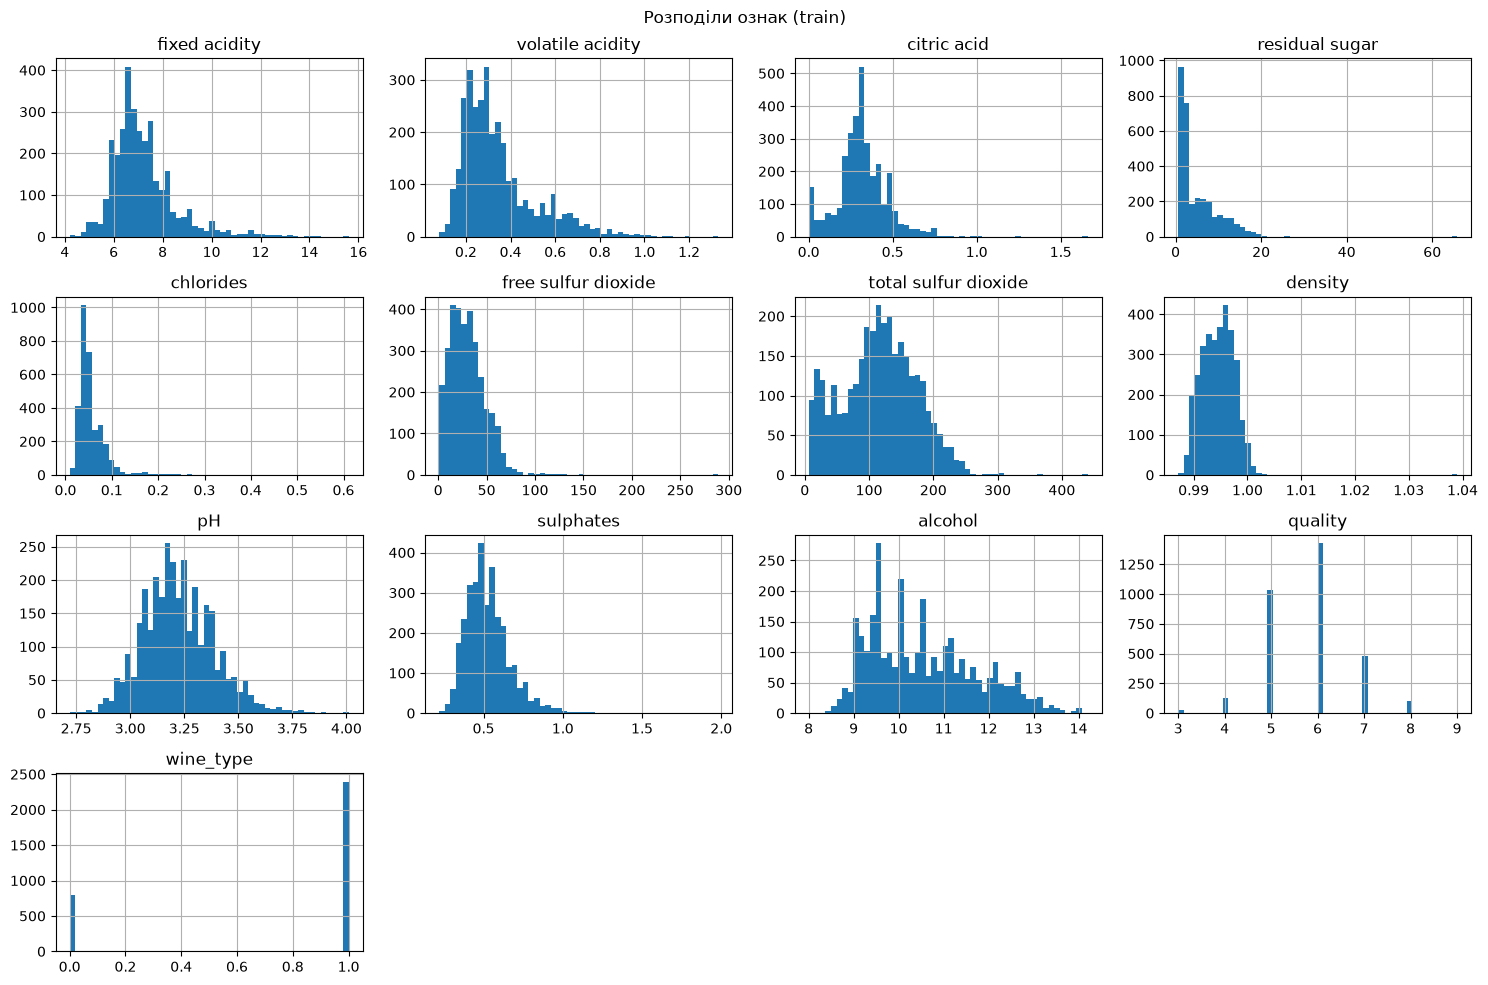

In [11]:
train_df.hist(bins=50, figsize=(15, 10))
plt.suptitle("Розподіли ознак (train)")
plt.tight_layout()
plt.show()

In [12]:
from scipy.stats import skew

print("Skewness за колонками (train):")
for col in train_df.columns:
    print(f"  {col:22s} {skew(train_df[col]):6.2f}")

print("\nРозподіл таргета quality:")
print(train_df[TARGET].value_counts().sort_index().to_string())

Skewness за колонками (train):
  fixed acidity            1.64
  volatile acidity         1.44
  citric acid              0.61
  residual sugar           1.89
  chlorides                4.70
  free sulfur dioxide      1.67
  total sulfur dioxide     0.08
  density                  1.01
  pH                       0.42
  sulphates                1.55
  alcohol                  0.56
  quality                  0.13
  wine_type               -1.16

Розподіл таргета quality:
quality
3      23
4     129
5    1036
6    1426
7     476
8      99
9       3


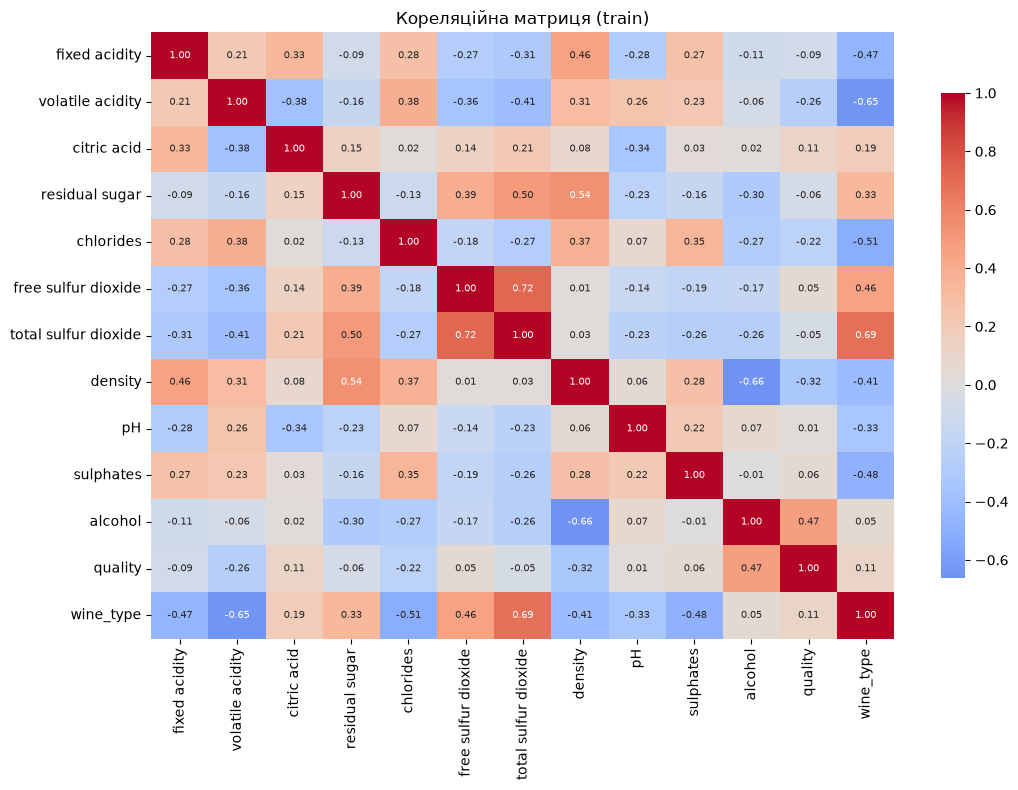

Кореляція ознак із таргетом quality:
alcohol                 0.468
density                -0.324
volatile acidity       -0.258
chlorides              -0.221
wine_type               0.113
citric acid             0.111
fixed acidity          -0.087
residual sugar         -0.060
sulphates               0.059
total sulfur dioxide   -0.053
free sulfur dioxide     0.053
pH                      0.014


In [13]:
plt.figure(figsize=(11, 8))
corr = train_df.corr(numeric_only=True)
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0,
            annot_kws={"size": 7}, cbar_kws={"shrink": 0.8})
plt.title("Кореляційна матриця (train)")
plt.tight_layout()
plt.show()

print("Кореляція ознак із таргетом quality:")
print(corr[TARGET].drop(TARGET).sort_values(key=abs, ascending=False).round(3).to_string())

#### Що впадає в очі

**1. Таргет `quality` — дискретний і сильно незбалансований.** Це оцінки дегустаторів цілими числами 3–9, причому ~77% усіх вин мають оцінку 5 або 6, а на краях (3 і 9) — лічені десятки прикладів. Формально це порядкова змінна, але за умовою лаби розв'язуємо як **регресію**. Практичний наслідок: модель добре вчиться на «середніх» винах і майже не має прикладів для дуже поганих/дуже хороших, тому на краях помилятиметься сильніше.

**2. Найсильніші предиктори:** `alcohol` (**+0.44**) — єдина ознака з помітним додатним зв'язком; далі `density` (−0.31), `volatile acidity` (−0.27, летка кислотність = оцтовий присмак) і `chlorides` (−0.20). Решта ознак майже не корелюють із таргетом лінійно — це вже натяк, що лінійна модель тут упреться в стелю.

**3. Мультиколінеарність — є, і суттєва:**
- `free sulfur dioxide` ↔ `total sulfur dioxide` = **0.72** (вільний SO₂ — частина загального, за означенням);
- `density` ↔ `alcohol` = **0.67** (спирт легший за воду, тому міцніше вино менш щільне);
- `residual sugar` ↔ `density` = **0.52** (цукор, навпаки, робить вино щільнішим);
- `wine_type` ↔ `total sulfur dioxide` = 0.69 і ↔ `volatile acidity` = 0.65 — біле й червоне справді різняться хімічно.

Тобто `density` — майже лінійна комбінація алкоголю й цукру. Для лінійної регресії це шкідливо: ваги корельованих ознак стають нестабільними й погано інтерпретуються.

**4. Скошені розподіли:** `chlorides` (skew **5.3**), `sulphates` (1.8), `residual sugar` (1.7), `fixed acidity` (1.7). Довгі праві хвости.

### 2.1.7. Обробка викидів

Дивлюсь на найпідозріліші значення й вирішую по кожному окремо, а не «відрізати все за 3σ».

In [14]:
for col in ["residual sugar", "density", "chlorides", "free sulfur dioxide", "total sulfur dioxide"]:
    s = train_df[col]
    print(f"{col:22s} max={s.max():9.3f}  p99={s.quantile(0.99):8.3f}  "
          f"median={s.median():7.3f}  max/p99={s.max() / s.quantile(0.99):5.2f}x")

print("\nНайекстремальніший рядок за residual sugar:")
print(train_df.loc[[train_df["residual sugar"].idxmax()]].T.to_string())

residual sugar         max=   65.800  p99=  18.105  median=  2.800  max/p99= 3.63x
density                max=    1.039  p99=   1.000  median=  0.995  max/p99= 1.04x
chlorides              max=    0.611  p99=   0.194  median=  0.047  max/p99= 3.15x
free sulfur dioxide    max=  289.000  p99=  77.545  median= 28.000  max/p99= 3.73x
total sulfur dioxide   max=  440.000  p99= 240.090  median=117.000  max/p99= 1.83x

Найекстремальніший рядок за residual sugar:
                           3653
fixed acidity           7.80000
volatile acidity        0.96500
citric acid             0.60000
residual sugar         65.80000
chlorides               0.07400
free sulfur dioxide     8.00000
total sulfur dioxide  160.00000
density                 1.03898
pH                      3.39000
sulphates               0.69000
alcohol                11.70000
quality                 6.00000
wine_type               1.00000


#### Рішення щодо викидів

Ключове питання — **звідки взялося значення**: це помилка вимірювання чи реальне рідкісне вино?

- **`residual sugar` до 65.8 г/л при медіані ~3** — це **не помилка**. Солодкі десертні білі вина (Sauternes, Eiswein) реально мають такий рівень цукру. Рядок фізично несуперечливий: разом із цукром у нього підвищена `density` (1.039) — рівно як і має бути.
- **`density` 1.039** — похідна від того самого цукру, той самий рядок.
- **`chlorides` зі skew 5.3** — солоність, у частини вин справді підвищена.

Оскільки це справжні вина, а не биті дані, **видаляти їх не можна** — модель має вміти працювати й з такими. Але лишати як є теж погано: одне значення в 20 разів більше за медіану отримує величезний важіль на MSE та на ваги лінійної моделі.

**Компроміс: не видаляю, а трансформую** — застосовую `log1p` до трьох найскошеніших ознак (`residual sugar`, `chlorides`, `sulphates`). Логарифм стискає довгий правий хвіст, не викидаючи жодного рядка: екстремум лишається найбільшим значенням, але перестає домінувати над рештою.

### 2.1.8. Інженерія ознак

Три зміни, кожна — відповідь на конкретне спостереження з EDA:

1. **`log1p` для `residual sugar`, `chlorides`, `sulphates`** — лікуємо скошеність (див. 2.1.7).
2. **`free_to_total_so2` = free SO₂ / total SO₂** замість сирого `free sulfur dioxide`. Дві ознаки корелювали на 0.72, бо вільний SO₂ — частина загального. Частка ж несе іншу інформацію: скільки консерванту ще «активне», а не зв'язане. Замінюю корельовану ознаку на змістовне відношення.
3. **Прибираю `density`** — вона на 0.67 корелює з `alcohol` і на 0.52 з `residual sugar`, тобто майже не несе власної інформації, зате псує стабільність ваг лінійної моделі.

Усі перетворення застосовуються **однаково до train/val/test**, і жодне з них не рахує статистик по всьому датасету (log1p і ділення — поелементні операції), тому витоку немає.

In [15]:
SKEWED_COLS = ["residual sugar", "chlorides", "sulphates"]

def engineer(df):
    d = df.copy()
    # 1. log1p для скошених ознак
    for col in SKEWED_COLS:
        d[f"log_{col.replace(' ', '_')}"] = np.log1p(d[col])
        d = d.drop(columns=[col])
    # 2. частка вільного SO2 від загального
    d["free_to_total_so2"] = d["free sulfur dioxide"] / d["total sulfur dioxide"]
    d = d.drop(columns=["free sulfur dioxide"])
    # 3. прибираємо мультиколінеарну density
    d = d.drop(columns=["density"])
    return d

train_df = engineer(train_df)
val_df = engineer(val_df)
test_df = engineer(test_df)

FEATURE_COLS = [c for c in train_df.columns if c != TARGET]
print("Фінальний набір ознак:", len(FEATURE_COLS))
for c in FEATURE_COLS:
    print("  -", c)
train_df.head()

Фінальний набір ознак: 11
  - fixed acidity
  - volatile acidity
  - citric acid
  - total sulfur dioxide
  - pH
  - alcohol
  - wine_type
  - log_residual_sugar
  - log_chlorides
  - log_sulphates
  - free_to_total_so2


,fixed acidity,volatile acidity,citric acid,total sulfur dioxide,pH,alcohol,quality,wine_type,log_residual_sugar,log_chlorides,log_sulphates,free_to_total_so2
3994,7.5,0.180,0.45,158.0,3.01,10.6,6,1,1.722767,0.040182,0.322083,0.424051
4985,6.7,0.230,0.17,100.0,3.07,9.5,5,1,0.832909,0.059212,0.438255,0.140000
4301,6.6,0.295,0.24,140.0,3.35,10.4,7,1,0.955511,0.038259,0.476234,0.207143
3976,5.8,0.280,0.30,114.0,3.32,12.5,7,1,0.916291,0.025668,0.470004,0.271930
6,7.3,0.650,0.00,21.0,3.39,10.0,7,0,0.788457,0.062975,0.385262,0.714286


## 2.2. Baseline: множинна лінійна регресія

### 2.2.1. Стандартизація ознак

`StandardScaler` навчається **тільки на train** (`fit_transform`), а до val/test застосовується вже навчений (`transform`). Інакше середнє й дисперсія val/test просочилися б у препроцесинг — той самий data leakage.

In [16]:
scaler = StandardScaler()
X_train = scaler.fit_transform(train_df[FEATURE_COLS])
X_val = scaler.transform(val_df[FEATURE_COLS])
X_test = scaler.transform(test_df[FEATURE_COLS])

y_train = train_df[TARGET].values.astype("float32")
y_val = val_df[TARGET].values.astype("float32")
y_test = test_df[TARGET].values.astype("float32")

print("Форма X_train:", X_train.shape)
print("Ознак:", len(FEATURE_COLS))

Форма X_train: (3192, 11)
Ознак: 11


### 2.2.2. Конвертуємо в тензори PyTorch

In [17]:
def to_tensor(X, y):
    return (
        torch.tensor(X, dtype=torch.float32).to(device),
        torch.tensor(y, dtype=torch.float32).unsqueeze(1).to(device),
    )

x_train_t, y_train_t = to_tensor(X_train, y_train)
x_val_t, y_val_t = to_tensor(X_val, y_val)
x_test_t, y_test_t = to_tensor(X_test, y_test)

print("x_train_t:", tuple(x_train_t.shape), "| y_train_t:", tuple(y_train_t.shape))

x_train_t: (3192, 11) | y_train_t: (3192, 1)


### 2.2.3. Спільна інфраструктура тренування

Одна функція `train_variant()` на всі варіанти — так порівняння буде чесним: однаковий цикл, однакові дані, однакове логування в TensorBoard, однакове збереження `.pt`. Різняться лише архітектура й гіперпараметри.

`set_seed()` викликається **перед створенням моделі**, щоб ініціалізація ваг була відтворюваною для кожного прогону.

In [18]:
N_FEATURES = X_train.shape[1]

RESULTS = []     # рядки підсумкової таблиці
MODELS = {}      # name -> навчена модель (для Gradio)
HISTORIES = {}   # name -> криві навчання

LOSSES = {"mse": torch.nn.MSELoss, "l1": torch.nn.L1Loss, "huber": torch.nn.HuberLoss}
OPTIMS = {"adam": torch.optim.Adam, "sgd": torch.optim.SGD}


def evaluate(model):
    """MSE / RMSE / MAE / R2 на test."""
    model.eval()
    with torch.no_grad():
        pred = model(x_test_t).cpu().numpy().flatten()
    mse = mean_squared_error(y_test, pred)
    return {
        "MSE": mse,
        "RMSE": mse ** 0.5,
        "MAE": mean_absolute_error(y_test, pred),
        "R2": r2_score(y_test, pred),
    }


def train_variant(name, build_fn, *, n_epochs=300, lr=0.01, optimizer="adam",
                  loss="mse", note="", verbose_every=None):
    set_seed()                       # відтворювана ініціалізація ваг
    model = build_fn().to(device)
    opt = OPTIMS[optimizer](model.parameters(), lr=lr)
    loss_fn = LOSSES[loss]()
    writer = SummaryWriter(log_dir=os.path.join(RUNS_DIR, name))

    hist = {"train": [], "val": []}
    for epoch in range(n_epochs):
        model.train()
        opt.zero_grad()
        train_loss = loss_fn(model(x_train_t), y_train_t)
        train_loss.backward()
        opt.step()

        model.eval()
        with torch.no_grad():
            val_loss = loss_fn(model(x_val_t), y_val_t).item()

        hist["train"].append(train_loss.item())
        hist["val"].append(val_loss)
        writer.add_scalar("Loss/train", train_loss.item(), epoch)
        writer.add_scalar("Loss/val", val_loss, epoch)

        if verbose_every and (epoch % verbose_every == 0 or epoch == n_epochs - 1):
            print(f"  epoch {epoch:4d}  train={train_loss.item():.4f}  val={val_loss:.4f}")

    writer.close()
    torch.save(model.state_dict(), os.path.join(MODELS_DIR, f"{name}.pt"))

    n_params = sum(p.numel() for p in model.parameters())
    metrics = evaluate(model)
    RESULTS.append({"model": name, **metrics, "params": n_params, "epochs": n_epochs,
                    "lr": lr, "optimizer": optimizer, "loss": loss, "note": note})
    MODELS[name] = model
    HISTORIES[name] = hist

    print(f"[{name}] params={n_params} | test MSE={metrics['MSE']:.4f} "
          f"RMSE={metrics['RMSE']:.4f} MAE={metrics['MAE']:.4f} R2={metrics['R2']:.4f}")
    return model


def plot_curves(names, title):
    plt.figure(figsize=(9, 4))
    for n in names:
        plt.plot(HISTORIES[n]["train"], label=f"{n} — train", alpha=0.8)
        plt.plot(HISTORIES[n]["val"], "--", label=f"{n} — val", alpha=0.8)
    plt.xlabel("Епоха"); plt.ylabel("Loss"); plt.title(title)
    plt.legend(fontsize=8); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

print("Інфраструктуру готово. Ознак на вході:", N_FEATURES)

Інфраструктуру готово. Ознак на вході: 11


### 2.2.4. Варіант #1 — лінійна регресія

`nn.Linear(n_features, 1)` — та сама множинна лінійна регресія, тренована градієнтним спуском. Це точка відліку для всього, що далі.

In [19]:
def build_linear():
    return torch.nn.Linear(N_FEATURES, 1)

linear_model = train_variant("linear", build_linear, n_epochs=150, lr=0.1,
                             optimizer="sgd", note="baseline: множинна лінійна регресія",
                             verbose_every=30)

  epoch    0  train=34.2682  val=22.3895
  epoch   30  train=0.5456  val=0.5548
  epoch   60  train=0.5447  val=0.5570
  epoch   90  train=0.5446  val=0.5574
  epoch  120  train=0.5446  val=0.5575
  epoch  149  train=0.5446  val=0.5575
[linear] params=12 | test MSE=0.4813 RMSE=0.6937 MAE=0.5419 R2=0.3341


### 2.2.5. Крива навчання лінійної регресії

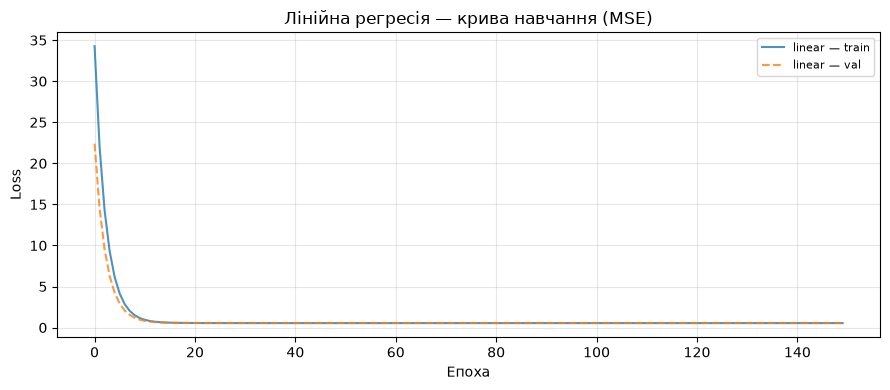

In [20]:
plot_curves(["linear"], "Лінійна регресія — крива навчання (MSE)")

### 2.2.6. Метрики на test і порівняння з константним бейзлайном

Константний бейзлайн — прогноз середнім `quality` по train для всіх вин. Його R² ≈ 0 за побудовою; будь-яка модель зобов'язана його побити.

In [21]:
baseline_pred = np.full_like(y_test, y_train.mean())
baseline_mse = mean_squared_error(y_test, baseline_pred)
BASELINE = {
    "model": "baseline_mean", "MSE": baseline_mse, "RMSE": baseline_mse ** 0.5,
    "MAE": mean_absolute_error(y_test, baseline_pred), "R2": r2_score(y_test, baseline_pred),
    "params": 0, "epochs": 0, "lr": None, "optimizer": None, "loss": None,
    "note": "константа: середнє quality по train",
}

print(f"Середнє quality (train): {y_train.mean():.3f}")
print(f"[baseline_mean] MSE={BASELINE['MSE']:.4f} RMSE={BASELINE['RMSE']:.4f} "
      f"MAE={BASELINE['MAE']:.4f} R2={BASELINE['R2']:.4f}")
print(f"[linear]        MSE={RESULTS[0]['MSE']:.4f} RMSE={RESULTS[0]['RMSE']:.4f} "
      f"MAE={RESULTS[0]['MAE']:.4f} R2={RESULTS[0]['R2']:.4f}")

Середнє quality (train): 5.787
[baseline_mean] MSE=0.7228 RMSE=0.8502 MAE=0.6838 R2=-0.0002
[linear]        MSE=0.4813 RMSE=0.6937 MAE=0.5419 R2=0.3341


### 2.2.7. Інтерпретація ваг

Ознаки стандартизовані, тому ваги зіставні між собою й показують відносний вплив.

             feature    weight
             alcohol  0.387168
    volatile acidity -0.220492
       log_sulphates  0.111769
   free_to_total_so2  0.097624
  log_residual_sugar  0.080615
       log_chlorides -0.062724
       fixed acidity -0.032753
         citric acid  0.031857
total sulfur dioxide -0.029621
           wine_type -0.023869
                  pH  0.005547


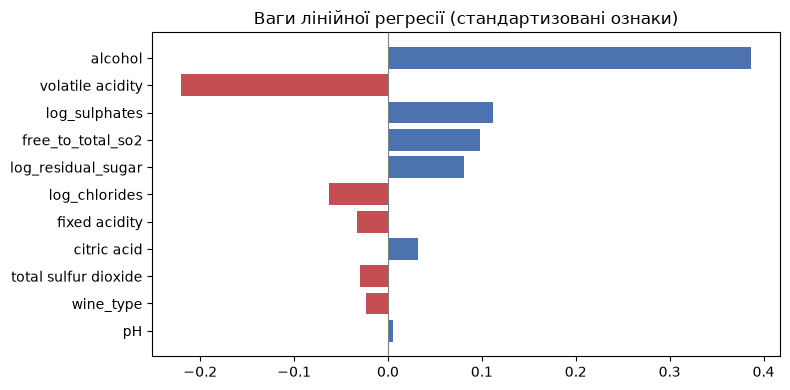

In [22]:
weights = linear_model.weight.detach().cpu().numpy().flatten()
weight_df = pd.DataFrame({"feature": FEATURE_COLS, "weight": weights})
weight_df["abs"] = weight_df["weight"].abs()
weight_df = weight_df.sort_values("abs", ascending=False).drop(columns="abs")
print(weight_df.to_string(index=False))

plt.figure(figsize=(8, 4))
plt.barh(weight_df["feature"][::-1], weight_df["weight"][::-1],
         color=["#4C72B0" if w > 0 else "#C44E52" for w in weight_df["weight"][::-1]])
plt.axvline(0, color="grey", lw=0.8)
plt.title("Ваги лінійної регресії (стандартизовані ознаки)")
plt.tight_layout(); plt.show()

## 2.3. Нейромережа: дві різні архітектури

Обидві відрізняються не косметично, а за двома осями одразу — **глибина/ширина** і **функція активації**:

- **`nn_v1_64_32_relu`** — 2 приховані шари (64 → 32), ReLU. Та сама архітектура, що в демо.
- **`nn_v2_128_64_32_leaky`** — 3 приховані шари, ширші (128 → 64 → 32), LeakyReLU замість ReLU.

Гіперпараметри поки однакові (Adam, lr=0.01, 300 епох), щоб порівнювати саме архітектури.

In [23]:
def build_nn_v1():
    return torch.nn.Sequential(
        torch.nn.Linear(N_FEATURES, 64),
        torch.nn.ReLU(),
        torch.nn.Linear(64, 32),
        torch.nn.ReLU(),
        torch.nn.Linear(32, 1),
    )

nn_v1 = train_variant("nn_v1_64_32_relu", build_nn_v1, n_epochs=300, lr=0.01,
                      optimizer="adam", note="2 приховані шари 64-32, ReLU",
                      verbose_every=60)

  epoch    0  train=34.3725  val=31.5973
  epoch   60  train=0.9190  val=1.0110
  epoch  120  train=0.6203  val=0.6762
  epoch  180  train=0.5315  val=0.5790
  epoch  240  train=0.4952  val=0.5355
  epoch  299  train=0.4757  val=0.5177
[nn_v1_64_32_relu] params=2881 | test MSE=0.4600 RMSE=0.6783 MAE=0.5332 R2=0.3634


In [24]:
def build_nn_v2():
    return torch.nn.Sequential(
        torch.nn.Linear(N_FEATURES, 128),
        torch.nn.LeakyReLU(0.01),
        torch.nn.Linear(128, 64),
        torch.nn.LeakyReLU(0.01),
        torch.nn.Linear(64, 32),
        torch.nn.LeakyReLU(0.01),
        torch.nn.Linear(32, 1),
    )

nn_v2 = train_variant("nn_v2_128_64_32_leaky", build_nn_v2, n_epochs=300, lr=0.01,
                      optimizer="adam", note="3 приховані шари 128-64-32, LeakyReLU",
                      verbose_every=60)

  epoch    0  train=35.1349  val=32.0985
  epoch   60  train=0.8131  val=0.8942
  epoch  120  train=0.5169  val=0.5702
  epoch  180  train=0.4653  val=0.5228
  epoch  240  train=0.4419  val=0.5144
  epoch  299  train=0.4262  val=0.5103
[nn_v2_128_64_32_leaky] params=11905 | test MSE=0.4596 RMSE=0.6779 MAE=0.5303 R2=0.3641


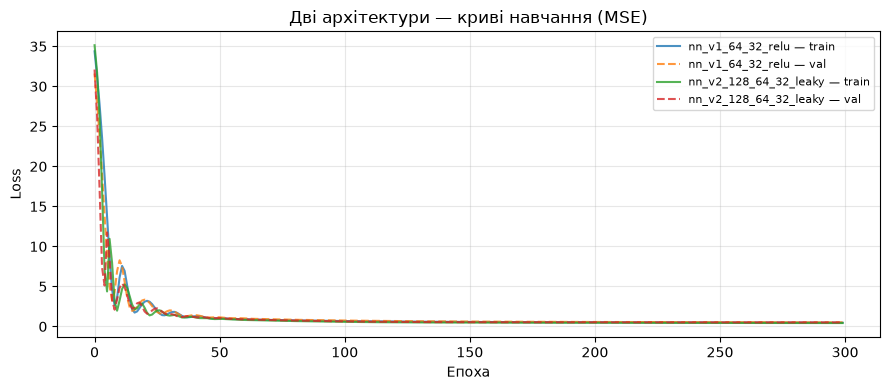

Краща архітектура за фінальним val_loss: nn_v2_128_64_32_leaky


In [25]:
plot_curves(["nn_v1_64_32_relu", "nn_v2_128_64_32_leaky"],
            "Дві архітектури — криві навчання (MSE)")

best_arch = min(["nn_v1_64_32_relu", "nn_v2_128_64_32_leaky"],
                key=lambda n: HISTORIES[n]["val"][-1])
BEST_BUILD = {"nn_v1_64_32_relu": build_nn_v1, "nn_v2_128_64_32_leaky": build_nn_v2}[best_arch]
print("Краща архітектура за фінальним val_loss:", best_arch)

## 2.4. Підбір гіперпараметрів: 5 змін, по одній за раз

Беру кращу архітектуру з 2.3 і змінюю **рівно один параметр** за раз відносно неї (Adam, lr=0.01, 300 епох, MSELoss) — інакше не зрозуміло, що саме дало ефект:

| варіант | що змінено |
|---|---|
| `..._lr0.001` | learning rate 0.01 → 0.001 |
| `..._sgd` | оптимізатор Adam → SGD |
| `..._ep1000` | епохи 300 → 1000 (перевірка гіпотези з питання 7) |
| `..._l1loss` | функція втрат MSE → L1 (експеримент для питання 2) |
| `..._huber` | функція втрат MSE → Huber (експеримент для питання 2) |

In [26]:
train_variant(f"{best_arch}_lr0.001", BEST_BUILD, n_epochs=300, lr=0.001,
              optimizer="adam", note="зміна 1: learning rate 0.01 -> 0.001")

train_variant(f"{best_arch}_sgd", BEST_BUILD, n_epochs=300, lr=0.01,
              optimizer="sgd", note="зміна 2: оптимізатор Adam -> SGD")

train_variant(f"{best_arch}_ep1000", BEST_BUILD, n_epochs=1000, lr=0.01,
              optimizer="adam", note="зміна 3: епохи 300 -> 1000", verbose_every=200)

[nn_v2_128_64_32_leaky_lr0.001] params=11905 | test MSE=0.4971 RMSE=0.7051 MAE=0.5519 R2=0.3122
[nn_v2_128_64_32_leaky_sgd] params=11905 | test MSE=0.5025 RMSE=0.7089 MAE=0.5602 R2=0.3047
  epoch    0  train=35.1349  val=32.0985
  epoch  200  train=0.4560  val=0.5190
  epoch  400  train=0.4002  val=0.5129
  epoch  600  train=0.3469  val=0.5354
  epoch  800  train=0.3055  val=0.5743
  epoch  999  train=0.2880  val=0.6342
[nn_v2_128_64_32_leaky_ep1000] params=11905 | test MSE=0.5768 RMSE=0.7595 MAE=0.5836 R2=0.2019


Sequential(
  (0): Linear(in_features=11, out_features=128, bias=True)
  (1): LeakyReLU(negative_slope=0.01)
  (2): Linear(in_features=128, out_features=64, bias=True)
  (3): LeakyReLU(negative_slope=0.01)
  (4): Linear(in_features=64, out_features=32, bias=True)
  (5): LeakyReLU(negative_slope=0.01)
  (6): Linear(in_features=32, out_features=1, bias=True)
)

In [27]:
train_variant(f"{best_arch}_l1loss", BEST_BUILD, n_epochs=300, lr=0.01,
              optimizer="adam", loss="l1", note="зміна 4: функція втрат MSE -> L1")

train_variant(f"{best_arch}_huber", BEST_BUILD, n_epochs=300, lr=0.01,
              optimizer="adam", loss="huber", note="зміна 5: функція втрат MSE -> Huber")

[nn_v2_128_64_32_leaky_l1loss] params=11905 | test MSE=0.4683 RMSE=0.6843 MAE=0.5280 R2=0.3521
[nn_v2_128_64_32_leaky_huber] params=11905 | test MSE=0.5067 RMSE=0.7118 MAE=0.5520 R2=0.2989


Sequential(
  (0): Linear(in_features=11, out_features=128, bias=True)
  (1): LeakyReLU(negative_slope=0.01)
  (2): Linear(in_features=128, out_features=64, bias=True)
  (3): LeakyReLU(negative_slope=0.01)
  (4): Linear(in_features=64, out_features=32, bias=True)
  (5): LeakyReLU(negative_slope=0.01)
  (6): Linear(in_features=32, out_features=1, bias=True)
)

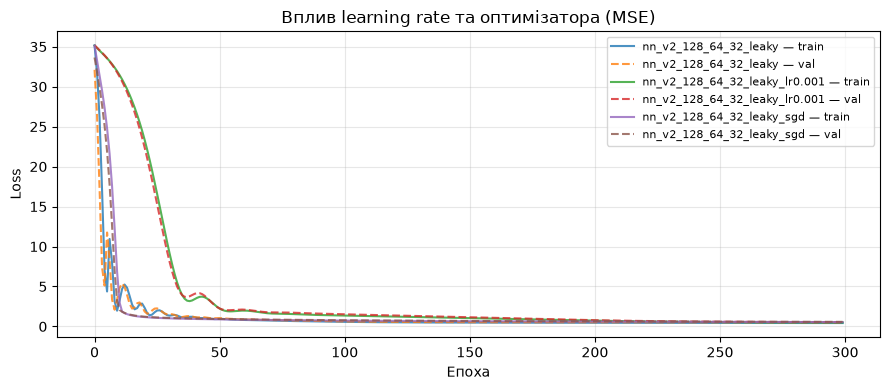

In [28]:
plot_curves([best_arch, f"{best_arch}_lr0.001", f"{best_arch}_sgd"],
            "Вплив learning rate та оптимізатора (MSE)")

## 2.5. Логування і порівняння всіх варіантів

Кожен варіант писав свої криві в окрему підпапку `runs/<назва>`, тож у TensorBoard їх можна накласти одна на одну. Нижче — зведена таблиця по test і збереження `results.csv`.

In [29]:
results_df = pd.DataFrame([BASELINE] + RESULTS)
results_df = results_df.sort_values("MSE").reset_index(drop=True)

results_df.to_csv(os.path.join(ARTIFACT_DIR, "results.csv"), index=False)

print("Порівняння всіх варіантів на TEST (відсортовано за MSE):\n")
print(results_df[["model", "MSE", "RMSE", "MAE", "R2", "params", "epochs",
                  "lr", "optimizer", "loss"]].round(4).to_string(index=False))
print("\nЗбережено results.csv")
print("Збережені моделі:", sorted(os.listdir(MODELS_DIR)))

Порівняння всіх варіантів на TEST (відсортовано за MSE):

                        model    MSE   RMSE    MAE      R2  params  epochs    lr optimizer  loss
        nn_v2_128_64_32_leaky 0.4596 0.6779 0.5303  0.3641   11905     300 0.010      adam   mse
             nn_v1_64_32_relu 0.4600 0.6783 0.5332  0.3634    2881     300 0.010      adam   mse
 nn_v2_128_64_32_leaky_l1loss 0.4683 0.6843 0.5280  0.3521   11905     300 0.010      adam    l1
                       linear 0.4813 0.6937 0.5419  0.3341      12     150 0.100       sgd   mse
nn_v2_128_64_32_leaky_lr0.001 0.4971 0.7051 0.5519  0.3122   11905     300 0.001      adam   mse
    nn_v2_128_64_32_leaky_sgd 0.5025 0.7089 0.5602  0.3047   11905     300 0.010       sgd   mse
  nn_v2_128_64_32_leaky_huber 0.5067 0.7118 0.5520  0.2989   11905     300 0.010      adam huber
 nn_v2_128_64_32_leaky_ep1000 0.5768 0.7595 0.5836  0.2019   11905    1000 0.010      adam   mse
                baseline_mean 0.7228 0.8502 0.6838 -0.0002       0   

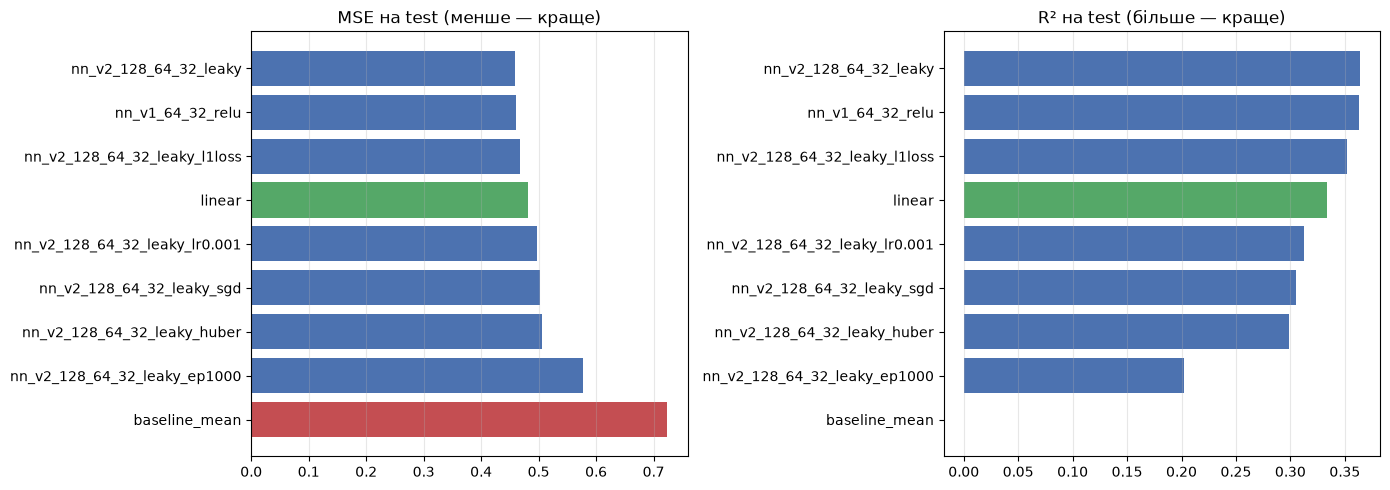

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
plot_df = results_df.sort_values("MSE")
colors = ["#C44E52" if m == "baseline_mean" else ("#55A868" if m == "linear" else "#4C72B0")
          for m in plot_df["model"]]

axes[0].barh(plot_df["model"][::-1], plot_df["MSE"][::-1], color=colors[::-1])
axes[0].set_title("MSE на test (менше — краще)"); axes[0].grid(alpha=0.3, axis="x")
axes[1].barh(plot_df["model"][::-1], plot_df["R2"][::-1], color=colors[::-1])
axes[1].set_title("R² на test (більше — краще)"); axes[1].grid(alpha=0.3, axis="x")
plt.tight_layout(); plt.show()

### 2.5.1. TensorBoard

Усі прогони лежать у `runs/`. Якщо inline-віджет не стартує (частий випадок поза Colab), TensorBoard відкривається командою з виводу.

In [31]:
try:
    ip = get_ipython()
    ip.run_line_magic("load_ext", "tensorboard")
    ip.run_line_magic("tensorboard", f"--logdir {RUNS_DIR}")
except Exception as e:
    print("Inline TensorBoard недоступний:", type(e).__name__, e)

print("\nПрогони в runs/:")
for d in sorted(os.listdir(RUNS_DIR)):
    print("  -", d)
print(f"\nЛокально:  tensorboard --logdir {RUNS_DIR}")

ERROR: Could not find `tensorboard`. Please ensure that your PATH
contains an executable `tensorboard` program, or explicitly specify
the path to a TensorBoard binary by setting the `TENSORBOARD_BINARY`
environment variable.


Прогони в runs/:
  - .DS_Store
  - linear
  - nn_v1_64_32_relu
  - nn_v2_128_64_32_leaky
  - nn_v2_128_64_32_leaky_ep1000
  - nn_v2_128_64_32_leaky_huber
  - nn_v2_128_64_32_leaky_l1loss
  - nn_v2_128_64_32_leaky_lr0.001
  - nn_v2_128_64_32_leaky_sgd

Локально:  tensorboard --logdir /Users/alex/Programs/Univercity/Systems AI/lab2/runs


## 2.6. Висновки: порівняння всіх варіантів

### Підсумкова таблиця (test)

| модель | MSE | RMSE | MAE | R² | параметрів |
|---|---|---|---|---|---|
| **nn_v2_128_64_32_leaky** | **0.4596** | 0.6779 | 0.5303 | **0.3641** | 11 905 |
| nn_v1_64_32_relu | 0.4600 | 0.6783 | 0.5332 | 0.3634 | 2 881 |
| nn_v2..._l1loss | 0.4683 | 0.6843 | **0.5280** | 0.3521 | 11 905 |
| linear | 0.4813 | 0.6937 | 0.5419 | 0.3341 | 12 |
| nn_v2..._lr0.001 | 0.4971 | 0.7051 | 0.5519 | 0.3122 | 11 905 |
| nn_v2..._sgd | 0.5025 | 0.7089 | 0.5602 | 0.3047 | 11 905 |
| nn_v2..._huber | 0.5067 | 0.7118 | 0.5520 | 0.2989 | 11 905 |
| nn_v2..._ep1000 | 0.5768 | 0.7595 | 0.5836 | 0.2019 | 11 905 |
| baseline_mean | 0.7228 | 0.8502 | 0.6838 | −0.0002 | 0 |

### Яка модель перемогла і наскільки суттєво?

Перемогла **`nn_v2_128_64_32_leaky`** з MSE=0.4596 (R²=0.364). Але масштаб перемоги треба називати чесно:

- проти константного бейзлайна — **−36%** MSE (0.7228 → 0.4596), тобто моделі справді вчаться;
- проти лінійної регресії — лише **−4.5%** (0.4813 → 0.4596);
- проти простішої мережі `nn_v1` — **−0.1%** (0.4600 → 0.4596), тобто **різниці практично немає**: 11 905 параметрів проти 2 881 не дали нічого.

### Чи виправдала себе нейромережа?

**Скоріше ні.** Приріст у 4.5% MSE над лінійною регресією куплений ціною в ~1000 разів більшу кількість параметрів (11 905 проти 12), повну втрату інтерпретованості й помітно довше тренування. У демо на California Housing нейромережа зменшила MSE на 33% — там нелінійність була суттєва. Тут — ні.

Причина видно ще з EDA: у Wine Quality лише одна ознака має помітний лінійний зв'язок із таргетом (`alcohol`, r=0.44), а сам таргет — це **суб'єктивна цілочисельна оцінка дегустатора** 3–9, де 77% вин — «5 або 6». Значна частина дисперсії — це шум людських оцінок, який не пояснити жодною хімією. Тому обидві моделі впираються в ту саму стелю R²≈0.35, і нелінійність тут майже нічого не додає.

Якби йшлося про продакшн — я б узяв лінійну регресію: втрата точності мінімальна, зате модель прозора й дешева.

### Що дало найбільший ефект — архітектура чи гіперпараметри?

Найбільший ефект дали **гіперпараметри, і то негативний**. Зміни архітектури зсували MSE в межах ±0.1%, а невдалий гіперпараметр псував результат на десятки відсотків:

- `ep1000` (300 → 1000 епох): **+25% MSE** (0.4596 → 0.5768) — найсильніший ефект у всій таблиці;
- `huber`: +10%; `sgd`: +9%; `lr0.001`: +8%.

**Чому 1000 епох зашкодили** — видно з логу тренування:

| епоха | train | val |
|---|---|---|
| 200 | 0.4560 | 0.5190 |
| 400 | 0.4002 | **0.5129** ← мінімум |
| 600 | 0.3469 | 0.5354 |
| 999 | 0.2880 | 0.6342 |

Після ~400-ї епохи train продовжує падати, а val **розвертається вгору** — мережа починає запам'ятовувати train замість узагальнення. Це підручниковий overfitting, і він же — пряма відповідь на питання 7: фіксоване число епох завжди буде здогадкою, правильне рішення — **early stopping за val_loss**.

### Експеримент із функцією втрат (до питання 2)

| функція втрат | MSE | MAE |
|---|---|---|
| MSE (базова) | **0.4596** | 0.5303 |
| L1 | 0.4683 | **0.5280** |
| Huber | 0.5067 | 0.5520 |

Результат рівно такий, якого й слід очікувати: **модель найкраща саме в тій метриці, яку оптимізувала**. Навчання з `L1Loss` дало найкращий MAE (0.5280), але програло в MSE, бо L1 не штрафує великі промахи квадратично. Практичний висновок: функцію втрат треба обирати під ту метрику, за якою модель оцінюватимуть, а не «за замовчуванням».

---
## 3. Gradio-застосунок: порівняння всіх варіантів наживо

Побудуйте аппку для своїх моделей

Застосунок дає покрутити всі ознаки повзунками й одразу побачити:
- прогноз **обраної** моделі;
- стовпчикову діаграму прогнозів **усіх** навчених варіантів на тих самих значеннях.

Повзунки відповідають **фінальному** набору ознак (після інженерії з 2.1.8) — саме те, що модель отримує на вхід.

> `prevent_thread_lock=True` — щоб `Run All` не зависав на цій клітинці. Щоб отримати публічне посилання, заміни на `share=True`.

In [32]:
import gradio as gr

def predict_all(*feature_values):
    x = scaler.transform(pd.DataFrame([feature_values], columns=FEATURE_COLS))
    x_t = torch.tensor(x, dtype=torch.float32).to(device)
    preds = {}
    for name, model in MODELS.items():
        model.eval()
        with torch.no_grad():
            preds[name] = float(model(x_t).item())
    return preds


def plot_comparison(*feature_values):
    preds = predict_all(*feature_values)
    fig, ax = plt.subplots(figsize=(7, 3.5))
    names = list(preds.keys())
    ax.bar(range(len(names)), [preds[n] for n in names], color="#4C72B0")
    ax.axhline(float(y_train.mean()), color="#C44E52", ls="--", label="бейзлайн (середнє)")
    ax.set_xticks(range(len(names)))
    ax.set_xticklabels(names, rotation=35, ha="right", fontsize=7)
    ax.set_ylabel("Прогноз quality")
    ax.set_title("Прогнози всіх варіантів")
    ax.legend(fontsize=8)
    plt.tight_layout()
    return fig


def run_prediction(selected_model, *feature_values):
    return predict_all(*feature_values)[selected_model], plot_comparison(*feature_values)


with gr.Blocks(title="Wine Quality — порівняння моделей") as demo:
    gr.Markdown("## Прогноз якості вина — лінійна регресія проти нейромереж")
    gr.Markdown(f"Датасет: **Wine Quality** ({len(train_df)} train / {len(test_df)} test). "
                f"Таргет: `quality` (оцінка 3–9).")
    with gr.Row():
        with gr.Column():
            sliders = [
                gr.Slider(
                    minimum=float(train_df[col].min()),
                    maximum=float(train_df[col].max()),
                    value=float(train_df[col].mean()),
                    label=col,
                )
                for col in FEATURE_COLS
            ]
            model_choice = gr.Dropdown(choices=list(MODELS.keys()),
                                       value=list(MODELS.keys())[0],
                                       label="Основна модель")
            submit_btn = gr.Button("Порахувати прогноз", variant="primary")
        with gr.Column():
            prediction_output = gr.Number(label="Прогноз обраної моделі")
            comparison_plot = gr.Plot(label="Порівняння всіх варіантів")

    submit_btn.click(fn=run_prediction,
                     inputs=[model_choice] + sliders,
                     outputs=[prediction_output, comparison_plot])

demo.launch(prevent_thread_lock=True)

* Running on local URL:  http://127.0.0.1:7860
* To create a public link, set `share=True` in `launch()`.
